In [1]:
### Data generation methods

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

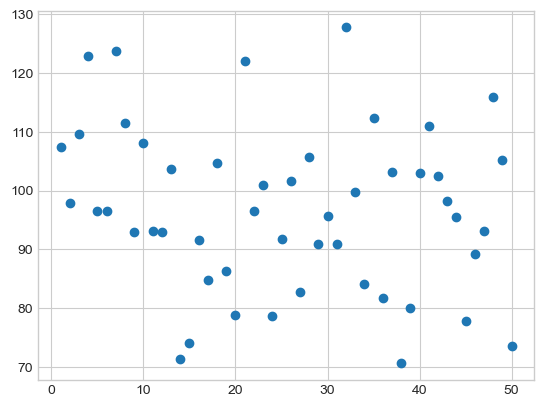

In [4]:
# Generating random data based on the normal distribution

np.random.seed(42)

# normal distribution's parameters
n = 50 # number of data
mean = 100 # arithmetic mean
sigma = 15 # standard deviation

# Data generating
data_normal = np.random.normal(
    loc=mean,
    scale=sigma,
    size=n)

x = np.arange(1, n + 1) # observation index

# Visualisation
plt.scatter(x, data_normal)

In [7]:
# Generating random data without using `random.normal()`
# Transforms numbers from a uniform distribution into a normal distribution, using the Box-Muller method

# The Box–Muller transformation is used to generate random numbers from a normal distribution  
# based on random numbers from a uniform distribution.
# Given a random number generator that produces values in the interval (0,1), 
# this transformation allows us to obtain numbers with a normal distribution from it. 

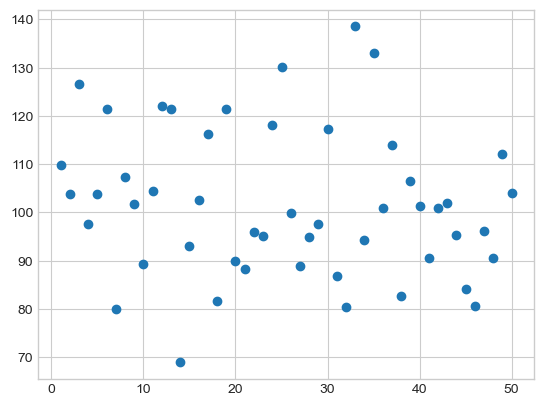

In [9]:
# Parameters
n = 50 # number of data
mu = 100 # arithmetic mean
sigma = 15 #standard deviation


# Box-Muller method
u1 = np.random.rand(n)
u2 = np.random.rand(n)
# U1 and U2 are independent random variables with a uniform distribution on the interval (0,1).

z = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2) #Box-Muller transformation formula

# Scalling
data_boxmuller = mu + sigma * z

x = np.arange(1, n + 1) # observation index

# Visualisation
plt.scatter(x, data_boxmuller)

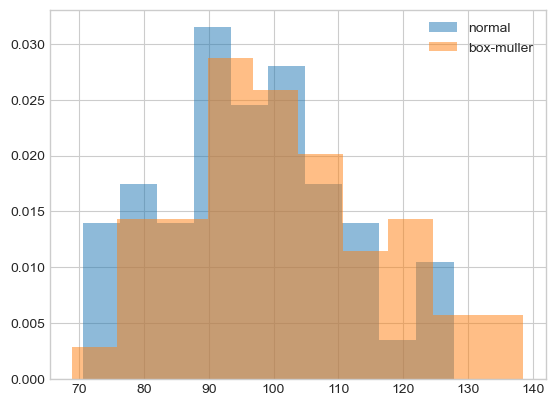

In [11]:
## Comparison of Data1 and Box-Muller data
plt.hist(data_normal, bins=10, alpha=0.5, density=True, label='normal')
plt.hist(data_boxmuller, bins=10, alpha=0.5, density=True, label='box-muller')

plt.legend()
plt.show()

## `random.normal()` doesn' t use the same algorithm as Box-Muller, so it will not generate identical values

In [13]:
# Generating nonlinear data with random noise, typical for linear regression or decision trees without pandas

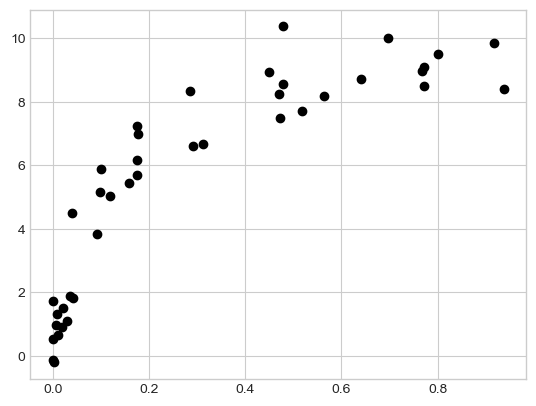

In [15]:
def make_data(N, err = 1.0, rseed=1):
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2 # squaring results in a uniform data distribution
    y = 10 - 1. / (X.ravel() + 0.1) # this function ensures nonlinearity, and adding 0.1 to the function prevents extremely large values and division by zero
    if err > 0:
        y += err * rng.randn(N) # adding noise to the data
    return X, y

X,y = make_data(40)

# Data visualization using matplotlib
X_test = np.linspace(-0.1,1.1, 500)[:, None] # The variable X_test stores one-dimensional 500 data points from -0.1 to 1.1
plt.scatter(X.ravel(), y, color='black')
axis = plt.axis()       